In [ ]:
# ▶️ STEP 1: Setup - Mount Drive, Import Libraries, Load & Save Data

import numpy as np
import json
import os
import pickle
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# Mount drive
drive.mount('/content/drive')

np.random.seed(42)

FEATURES_DIR = "/content/drive/MyDrive/Feature Detection File for all subjects"
TIMESERIES_DIR = "/content/drive/MyDrive/Filtered EEG Files"
CLIP_EMB_PATH = "/content/drive/MyDrive/clip_embeddings_new_Old_Dataset.npy"

print("\n--- Loading Feature Files ---")

feature_json_paths = list(Path(FEATURES_DIR).rglob("*_processed_features.json"))

all_data = []
clean_data = []

for file_path in feature_json_paths:
    with open(file_path, 'r') as f:
        data = json.load(f)
        all_data.extend(data)

print("Total trials:", len(all_data))

for trial in all_data:
    if np.sum(np.abs(trial['features'][0])) > 1e-9:
        clean_data.append(trial)

print("Clean samples:", len(clean_data))

y_raw = np.array([trial['label'] for trial in clean_data])
X_raw = np.array([trial['features'] for trial in clean_data])

# -------- Feature scaling --------

num_samples, num_channels, num_features = X_raw.shape

X_reshaped = X_raw.reshape(num_samples, num_channels * num_features)

scaler = StandardScaler()

X_scaled_features = scaler.fit_transform(X_reshaped)

# -------- Small Feature Noise --------

feature_noise = np.random.normal(0, 0.01, X_scaled_features.shape)
X_scaled_features = X_scaled_features + feature_noise

print("Feature shape:", X_scaled_features.shape)

# -------- Load EEG Timeseries --------

filtered_json_paths = list(Path(TIMESERIES_DIR).rglob("*_filtered_eeg.json"))

all_trials_data = []
all_trials_labels = []

for file_path in filtered_json_paths:

    with open(file_path, 'r') as f:

        data = json.load(f)

        for trial in data:

            all_trials_data.append(np.array(trial['eeg_data']))
            all_trials_labels.append(trial['label'])

X_timeseries = np.array(all_trials_data).transpose(0, 2, 1)

# -------- Small EEG Sensor Noise --------

ts_noise = np.random.normal(0, 0.005, X_timeseries.shape)
X_timeseries = X_timeseries + ts_noise

y_timeseries_str = np.array(all_trials_labels)

print("Timeseries shape:", X_timeseries.shape)

# -------- Load CLIP --------

clip_embeddings = np.load(CLIP_EMB_PATH, allow_pickle=True).item()

print("CLIP classes:", list(clip_embeddings.keys()))

# -------- Save dataset --------

data_to_save = {

'X_raw': X_raw,
'y_raw': y_raw,
'X_scaled_features': X_scaled_features,
'X_timeseries': X_timeseries,
'y_timeseries_str': y_timeseries_str,
'clip_embeddings': clip_embeddings

}

with open("all_data_new.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

print("Dataset saved → all_data_new.pkl")

Mounted at /content/drive

--- Loading Feature Files ---
Total trials: 2136
Clean samples: 2086
Feature shape: (2086, 40)
Timeseries shape: (2259, 375, 2)
CLIP classes: ['triangle', 'circle', 'square']
Dataset saved → all_data_new.pkl


In [ ]:
# === Load the dataset dictionary created from Step 1 ===
import pickle

with open("all_data_new.pkl", "rb") as f:
    data = pickle.load(f)

X_raw = data["X_raw"]                         # shape: (N, 2, 20)
y_raw = data["y_raw"]                         # labels (strings)
X_scaled_features = data["X_scaled_features"] # shape: (N, 40)
clip_embeddings = data["clip_embeddings"]     # dict: class → CLIP vector


In [ ]:
# === Build PyTorch Dataset for Feature-Based Models ===
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

# Convert label strings → integer classes
unique_labels = sorted(list(set(y_raw)))
label_to_idx = {lab: i for i, lab in enumerate(unique_labels)}
y_int = np.array([label_to_idx[l] for l in y_raw])

# Convert CLIP class dict → class embedding matrix
clip_matrix = np.stack([clip_embeddings[k] for k in unique_labels]).astype(np.float32)
clip_matrix = torch.tensor(clip_matrix)

class FeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

ds = FeatureDataset(X_scaled_features, y_int)

# Train/validation split
from sklearn.model_selection import train_test_split
idx_train, idx_val = train_test_split(np.arange(len(ds)), test_size=0.2, stratify=y_int, random_state=42)

train_ds = torch.utils.data.Subset(ds, idx_train)
val_ds   = torch.utils.data.Subset(ds, idx_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

print("Feature-based dataset ready!")
print("Train size:", len(train_ds), "Val size:", len(val_ds))


Feature-based dataset ready!
Train size: 1668 Val size: 418


# Exp 1 Hybrid EEG Model with CNN+MLP

In [ ]:
class HybridDataset(Dataset):
    def __init__(self, X_feat, X_ts, y):
        self.Xf = torch.tensor(X_feat, dtype=torch.float32)
        self.Xt = torch.tensor(X_ts, dtype=torch.float32)
        self.y  = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.Xf[idx], self.Xt[idx], self.y[idx]

# Load from your existing data dict:
X_raw = data["X_raw"]
X_scaled = data["X_scaled_features"]
X_ts = data["X_timeseries"]           # (N, time, channels)
y_raw = data["y_raw"]

# Label encoding
unique_labels = sorted(list(set(y_raw)))
label_to_idx = {lab:i for i,lab in enumerate(unique_labels)}
y_int = np.array([label_to_idx[l] for l in y_raw])

# Train/Val split
idx_train, idx_val = train_test_split(
    np.arange(len(y_int)), test_size=0.2, stratify=y_int, random_state=42)

train_ds = HybridDataset(X_scaled[idx_train], X_ts[idx_train], y_int[idx_train])
val_ds   = HybridDataset(X_scaled[idx_val],   X_ts[idx_val],   y_int[idx_val])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)


In [ ]:
class HybridEEGModel(nn.Module):
    def __init__(self, feat_dim=40, num_classes=3, emb_dim=256):
        super().__init__()

        # ----- 1D CNN for raw EEG -----
        self.conv1 = nn.Conv1d(8, 32, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)

        # ----- Feature MLP -----
        self.mlp = nn.Sequential(
            nn.Linear(feat_dim, 128),
            nn.ReLU(),
            nn.Linear(128, emb_dim)
        )

        # ----- Fusion layer -----
        self.fc_fusion = nn.Linear(128 + emb_dim, emb_dim)
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x_feat, x_ts):
        # x_ts shape: (B, time, channels) → (B, channels, time)
        x_ts = x_ts.permute(0, 2, 1)

        # CNN
        x = F.relu(self.conv1(x_ts))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(x).squeeze(-1)  # (B,128)

        # Feature MLP
        f = self.mlp(x_feat)  # (B, emb_dim)

        # Fusion
        z = torch.cat([x, f], dim=1)
        z = F.relu(self.fc_fusion(z))

        logits = self.classifier(z)
        return z, logits


Using device: cuda
Using existing data in memory.
Feature shape: (2110, 40)
Timeseries shape: (2259, 375, 2)
Labels: 2110
Classes: [np.str_('circle'), np.str_('square'), np.str_('triangle')]
Num classes: 3
Train size: 1688 Val size: 422

Training Started...

Epoch 1/50 | TrainLoss=57.734 | ValAcc=0.412
Epoch 2/50 | TrainLoss=54.835 | ValAcc=0.441
Epoch 3/50 | TrainLoss=52.457 | ValAcc=0.521
Epoch 4/50 | TrainLoss=49.869 | ValAcc=0.481
Epoch 5/50 | TrainLoss=48.228 | ValAcc=0.500
Epoch 6/50 | TrainLoss=45.903 | ValAcc=0.533
Epoch 7/50 | TrainLoss=42.930 | ValAcc=0.536
Epoch 8/50 | TrainLoss=41.095 | ValAcc=0.543
Epoch 9/50 | TrainLoss=38.240 | ValAcc=0.550
Epoch 10/50 | TrainLoss=36.486 | ValAcc=0.528
Epoch 11/50 | TrainLoss=35.837 | ValAcc=0.526
Epoch 12/50 | TrainLoss=33.283 | ValAcc=0.528
Epoch 13/50 | TrainLoss=31.206 | ValAcc=0.566
Epoch 14/50 | TrainLoss=30.132 | ValAcc=0.536
Epoch 15/50 | TrainLoss=27.956 | ValAcc=0.557
Epoch 16/50 | TrainLoss=26.754 | ValAcc=0.578
Epoch 17/50 | 

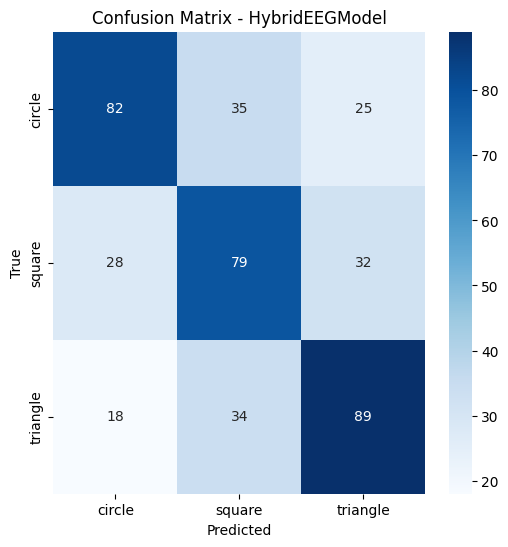

In [ ]:
# ============================================================
#  HYBRID EEG MODEL TRAINING (CNN + MLP FEATURE FUSION)
#  Works with:
#    X_scaled_features (N,40)
#    X_timeseries (N,time,channels=2)
#    y_raw labels
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ------------------------------------------------------------
# LOAD DATA (if already loaded from your .pkl, this will skip)
# ------------------------------------------------------------
try:
    X_scaled_features
    X_ts
    y_raw
    print("Using existing data in memory.")
except:
    import pickle
    with open("all_data_new.pkl", "rb") as f:
        data = pickle.load(f)

    X_scaled_features = data["X_scaled_features"]          # (N,40)
    X_ts = data["X_timeseries"]                            # (N,time,2)
    y_raw = data["y_timeseries_str"]                       # (N,)

print("Feature shape:", X_scaled_features.shape)
print("Timeseries shape:", X_ts.shape)
print("Labels:", len(y_raw))

# ------------------------------------------------------------
# LABEL ENCODING
# ------------------------------------------------------------
unique_labels = sorted(list(set(y_raw)))
label_to_idx = {lab:i for i,lab in enumerate(unique_labels)}
y_int = np.array([label_to_idx[l] for l in y_raw])
num_classes = len(unique_labels)

print("Classes:", unique_labels)
print("Num classes:", num_classes)

# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------
class HybridDataset(Dataset):
    def __init__(self, X_feat, X_ts, y):
        self.Xf = torch.tensor(X_feat, dtype=torch.float32)
        self.Xt = torch.tensor(X_ts, dtype=torch.float32)
        self.y  = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.Xf[idx], self.Xt[idx], self.y[idx]

# ------------------------------------------------------------
# TRAIN / VAL SPLIT
# ------------------------------------------------------------
idx_train, idx_val = train_test_split(
    np.arange(len(y_int)),
    test_size=0.2,
    stratify=y_int,
    random_state=42
)

train_ds = HybridDataset(X_scaled_features[idx_train], X_ts[idx_train], y_int[idx_train])
val_ds   = HybridDataset(X_scaled_features[idx_val],   X_ts[idx_val],   y_int[idx_val])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)

print("Train size:", len(train_ds), "Val size:", len(val_ds))

# ------------------------------------------------------------
# HYBRID MODEL (CNN + MLP FUSION)
# ------------------------------------------------------------
class HybridEEGModel(nn.Module):
    def __init__(self, feat_dim=40, num_classes=3, emb_dim=256):
        super().__init__()

        # ----- 1D CNN for raw EEG (channels = 2) -----
        self.conv1 = nn.Conv1d(2, 32, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)

        # ----- MLP for your handcrafted features -----
        self.mlp = nn.Sequential(
            nn.Linear(feat_dim, 128),
            nn.ReLU(),
            nn.Linear(128, emb_dim)
        )

        # ----- Fusion & classifier -----
        self.fc_fusion = nn.Linear(128 + emb_dim, emb_dim)
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x_feat, x_ts):

        # ALWAYS convert (B, time, channels) → (B, channels, time)
        x_ts = x_ts.permute(0, 2, 1)

        # CNN branch
        x = F.relu(self.conv1(x_ts))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(x).squeeze(-1)    # → (B,128)

        # Feature MLP branch
        f = self.mlp(x_feat)

        # Fusion
        z = torch.cat([x, f], dim=1)
        z = F.relu(self.fc_fusion(z))

        logits = self.classifier(z)
        return z, logits

# ------------------------------------------------------------
# TRAINING LOOP
# ------------------------------------------------------------
model = HybridEEGModel(
    feat_dim=X_scaled_features.shape[1],
    num_classes=num_classes
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 50

print("\nTraining Started...\n")

for ep in range(epochs):
    model.train()
    total_loss = 0

    for Xf, Xt, yb in train_loader:
        Xf, Xt, yb = Xf.to(device), Xt.to(device), yb.to(device)

        _, logits = model(Xf, Xt)
        loss = F.cross_entropy(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # ---- VALIDATION ----
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for Xf, Xt, yb in val_loader:
            Xf, Xt = Xf.to(device), Xt.to(device)
            _, logits = model(Xf, Xt)
            p = logits.argmax(dim=1).cpu().numpy()
            preds.extend(p)
            labels.extend(yb.numpy())

    acc = accuracy_score(labels, preds)
    print(f"Epoch {ep+1}/{epochs} | TrainLoss={total_loss:.3f} | ValAcc={acc:.3f}")

print("\nTraining Complete.")

# ------------------------------------------------------------
# SAVE MODEL
# ------------------------------------------------------------
torch.save(model.state_dict(), "hybrid_eeg_model.pth")
print("Model saved as hybrid_eeg_model.pth")

# Save label mapping for inference
import json
json.dump(unique_labels, open("label_mapping.json","w"))
print("Label mapping saved as label_mapping.json")

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=unique_labels,
            yticklabels=unique_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - HybridEEGModel")
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert to numpy arrays
labels_np = np.array(labels)
preds_np = np.array(preds)

# Metrics
acc = accuracy_score(labels_np, preds_np)
prec = precision_score(labels_np, preds_np, average='weighted')
rec  = recall_score(labels_np, preds_np, average='weighted')
f1   = f1_score(labels_np, preds_np, average='weighted')

print("\n----- VALIDATION METRICS -----")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")



----- VALIDATION METRICS -----
Accuracy:  0.6209
Precision: 0.6208
Recall:    0.6209
F1 Score:  0.6198


# t-SNE for Hybrid EEG Model(CNN+MLP Fusion)

✅ HybridEEGModel loaded
Embedding matrix shape: (422, 256)


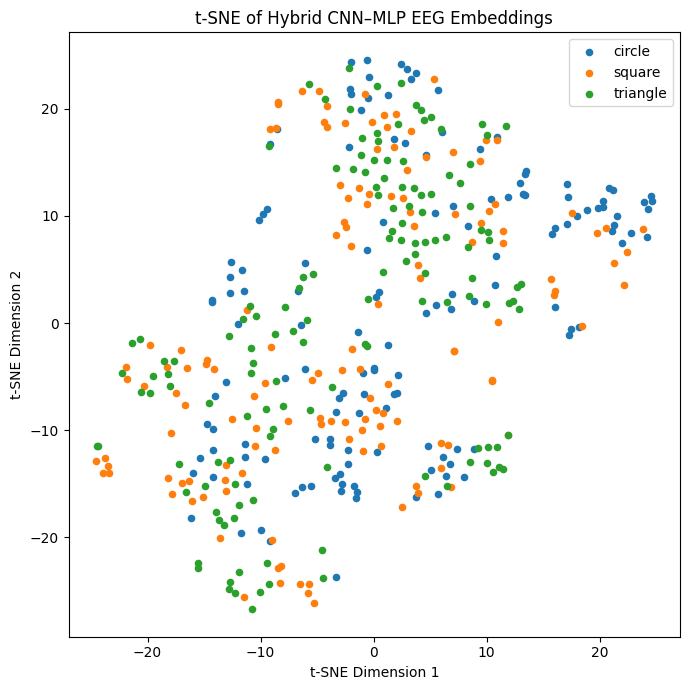

In [ ]:
# ============================================================
# t-SNE Visualization – Hybrid EEG Model (CNN + MLP Fusion)
# Matched with TriFusion & all baseline models
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# 1. Load trained model
# ------------------------------------------------------------
model = HybridEEGModel(
    feat_dim=X_scaled_features.shape[1],
    num_classes=len(unique_labels)
).to(device)

model.load_state_dict(torch.load("hybrid_eeg_model.pth", map_location=device))
model.eval()
print("✅ HybridEEGModel loaded")

# ------------------------------------------------------------
# 2. Extract embeddings from validation set
# ------------------------------------------------------------
Z_list = []
y_list = []

with torch.no_grad():
    for Xf, Xt, yb in val_loader:
        Xf = Xf.to(device)
        Xt = Xt.to(device)

        z, _ = model(Xf, Xt)     # 🔹 fused embedding
        Z_list.append(z.cpu())
        y_list.append(yb)

Z = torch.cat(Z_list, dim=0).numpy()
y_all = torch.cat(y_list, dim=0).numpy()

print("Embedding matrix shape:", Z.shape)

# ------------------------------------------------------------
# 3. t-SNE
# ------------------------------------------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)

Z_2d = tsne.fit_transform(Z)

# ------------------------------------------------------------
# 4. Plot (EXACT SAME STYLE AS TRIFUSION)
# ------------------------------------------------------------
plt.figure(figsize=(7, 7))

for lab, lab_name in enumerate(unique_labels):
    idx = np.where(y_all == lab)[0]
    plt.scatter(
        Z_2d[idx, 0],
        Z_2d[idx, 1],
        s=20,
        label=lab_name
    )

plt.legend()
plt.title("t-SNE of Hybrid CNN–MLP EEG Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


# Exp 2: 2-Channel Multi-Scale CNN + SE Attention + Feature-Fusion Hybrid EEG Model

Device: cuda
Using in-memory variables.
Feature shape: (2110, 40)
Timeseries shape: (2259, 375, 2)
Num trials: 2110
Classes: [np.str_('circle'), np.str_('square'), np.str_('triangle')] num_classes: 3
Train/Val sizes: 1688 422
Model params: 106615

Training Started...


Epoch 1/80 | TrainLoss=1.1999 | ValAcc=0.4028 | Prec=0.4088 | Rec=0.4028 | F1=0.4026
  ✓ Saved best model.


Epoch 2/80 | TrainLoss=1.1118 | ValAcc=0.4147 | Prec=0.4038 | Rec=0.4147 | F1=0.3935
  ✓ Saved best model.


Epoch 3/80 | TrainLoss=1.0704 | ValAcc=0.4645 | Prec=0.4672 | Rec=0.4645 | F1=0.4503
  ✓ Saved best model.


Epoch 4/80 | TrainLoss=1.0344 | ValAcc=0.5284 | Prec=0.5310 | Rec=0.5284 | F1=0.5163
  ✓ Saved best model.


...

Epoch 45/80 | TrainLoss=0.5024 | ValAcc=0.6209 | Prec=0.6233 | Rec=0.6209 | F1=0.6209


Epoch 46/80 | TrainLoss=0.5411 | ValAcc=0.6280 | Prec=0.6372 | Rec=0.6280 | F1=0.6292


Epoch 47/80 | TrainLoss=0.5267 | ValAcc=0.6090 | Prec=0.6100 | Rec=0.6090 | F1=0.6082


Epoch 48/80 | TrainLoss=0.5081 | ValAcc=0.6256 | Prec=0.6305 | Rec=0.6256 | F1=0.6264


Epoch 49/80 | TrainLoss=0.5273 | ValAcc=0.6185 | Prec=0.6252 | Rec=0.6185 | F1=0.6200
Early stopping (no improvement for 12 epochs).
Training finished. Best val acc: 0.6303317535545023

FINAL METRICS
Accuracy: 0.6303
Precision: 0.6314
Recall: 0.6303
F1: 0.6285


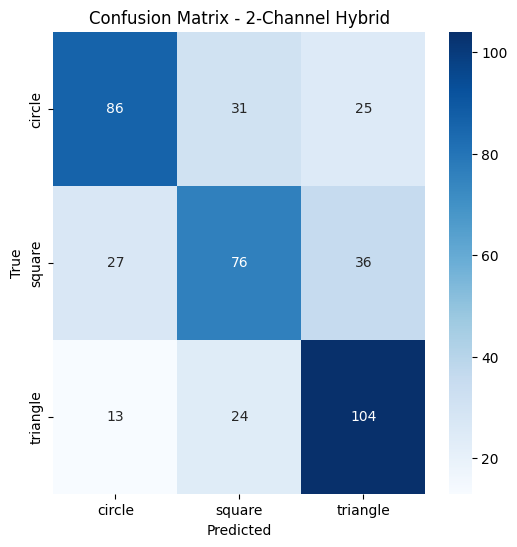

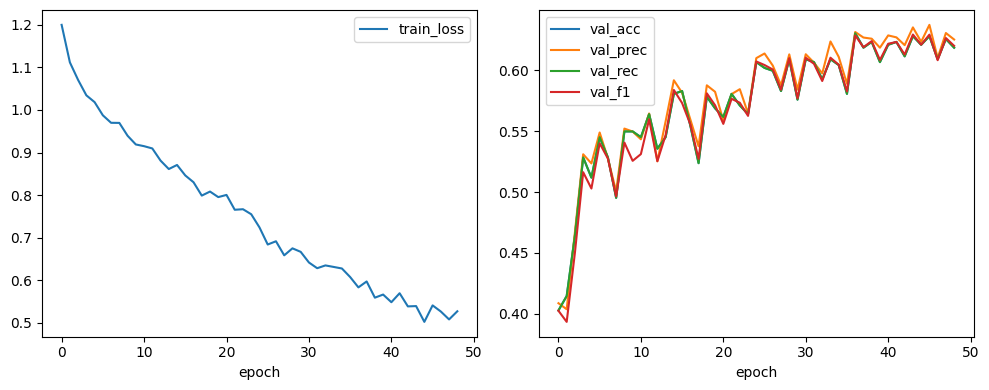

Label mapping saved to label_mapping.json; model saved to best_2ch_eeg_model.pth


In [ ]:
# ================= 2-Channel State-of-the-Art EEG Hybrid =================
# Works with:
#   - X_scaled_features (N, feat_dim)    e.g. (2110, 40)
#   - X_timeseries     (N, time, 2)      e.g. (2110, 375, 2)
#   - y_raw            (N,)
# ========================================================================

import os, pickle, random, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ---------------- reproducibility ----------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------------- load data (or reuse memory) ----------------
try:
    X_scaled_features   # noqa
    X_ts                # noqa
    y_raw               # noqa
    print("Using in-memory variables.")
except NameError:
    with open("all_data_new.pkl", "rb") as f:
        data = pickle.load(f)
    X_scaled_features = data["X_scaled_features"]
    X_ts = data["X_timeseries"]
    if "y_timeseries_str" in data:
        y_raw = data["y_timeseries_str"]
    elif "y_raw" in data:
        y_raw = data["y_raw"]
    else:
        raise KeyError("Label key not found (expected y_timeseries_str or y_raw).")

print("Feature shape:", X_scaled_features.shape)
print("Timeseries shape:", X_ts.shape)
print("Num trials:", len(y_raw))

# ---------------- label encoding ----------------
unique_labels = sorted(list(set(y_raw)))
label_to_idx = {lab: i for i, lab in enumerate(unique_labels)}
y_int = np.array([label_to_idx[l] for l in y_raw])
num_classes = len(unique_labels)
print("Classes:", unique_labels, "num_classes:", num_classes)

# ---------------- dataset ----------------
class HybridDataset(Dataset):
    def __init__(self, Xf, Xt, y):
        self.Xf = torch.tensor(Xf, dtype=torch.float32)
        self.Xt = torch.tensor(Xt, dtype=torch.float32)
        self.y  = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.Xf[idx], self.Xt[idx], self.y[idx]

# ---------------- split ----------------
idx = np.arange(len(y_int))
idx_train, idx_val = train_test_split(idx, test_size=0.20, stratify=y_int, random_state=SEED)

train_ds = HybridDataset(X_scaled_features[idx_train], X_ts[idx_train], y_int[idx_train])
val_ds   = HybridDataset(X_scaled_features[idx_val],   X_ts[idx_val],   y_int[idx_val])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)

print("Train/Val sizes:", len(train_ds), len(val_ds))

# ---------------- model components ----------------
class MultiScaleTemporalBlock(nn.Module):
    """Parallel Conv1D branches with different kernel sizes to capture multi-scale temporal features."""
    def __init__(self, in_ch, out_ch_per_branch=32, kernel_sizes=(3,7,15), dilation=(1,1,1)):
        super().__init__()
        self.branches = nn.ModuleList()
        for k, d in zip(kernel_sizes, dilation):
            pad = (k - 1) // 2 * d
            self.branches.append(
                nn.Sequential(
                    nn.Conv1d(in_ch, out_ch_per_branch, kernel_size=k, padding=pad, dilation=d, bias=False),
                    nn.BatchNorm1d(out_ch_per_branch),
                    nn.ReLU(),
                    nn.AdaptiveAvgPool1d(1)   # collapse time -> 1
                )
            )
    def forward(self, x):
        # x: (B, channels, time)
        outs = [b(x).squeeze(-1) for b in self.branches]  # each -> (B, out_ch)
        return torch.cat(outs, dim=1)  # (B, out_ch_total)

class SEBlock(nn.Module):
    """Squeeze-and-Excitation for channel attention (works with small channel counts)."""
    def __init__(self, in_dim, reduction=8):
        super().__init__()
        r = max(1, in_dim // reduction)
        self.fc1 = nn.Linear(in_dim, r)
        self.fc2 = nn.Linear(r, in_dim)
    def forward(self, x):
        # x: (B, feat_dim)
        s = x.mean(dim=0, keepdim=True) if x.dim()==2 else x.mean(dim=1, keepdim=True)
        # but typical SE uses global pooling across time/channel — here x is already pooled -> use x itself
        z = torch.relu(self.fc1(x))
        z = torch.sigmoid(self.fc2(z))
        return x * z

class FeatureEncoder(nn.Module):
    def __init__(self, in_dim=40, hidden=128, out_dim=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
            nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)

class TwoChannelEEGModel(nn.Module):
    def __init__(self, time_steps, feat_dim, num_classes,
                 in_channels=2, branch_ch=48, kernels=(3,7,15)):
        super().__init__()
        # Multi-scale temporal branches working on raw multichannel signal
        self.mst = MultiScaleTemporalBlock(in_ch=in_channels, out_ch_per_branch=branch_ch, kernel_sizes=kernels)
        mst_out_dim = branch_ch * len(kernels)

        # small depth conv across channels (depthwise-like) to mix channels if useful
        # here we expand channels to a small vector then pool
        self.channel_conv = nn.Sequential(
            nn.Conv1d(in_channels, in_channels*8, kernel_size=1, bias=False),
            nn.BatchNorm1d(in_channels*8),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        # The channel_conv returns (B, in_ch*8, 1) -> squeeze -> (B, in_ch*8)
        channel_feat_dim = in_channels*8

        # SE block applied to concatenated temporal + channel features
        combined_dim = mst_out_dim + channel_feat_dim
        self.se = SEBlock(combined_dim, reduction=8)

        # feature encoder for precomputed features
        self.feat_enc = FeatureEncoder(in_dim=feat_dim, hidden=128, out_dim=128, dropout=0.3)

        # fusion + classifier
        fusion_dim = combined_dim + 128
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.4)
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, feat, ts):
        # feat: (B, feat_dim)
        # ts: (B, time, channels) -> convert to (B, channels, time)
        ts = ts.permute(0,2,1)  # (B, channels, time)

        temporal = self.mst(ts)            # (B, mst_out_dim)
        channel = self.channel_conv(ts).squeeze(-1)  # (B, channel_feat_dim)

        combined = torch.cat([temporal, channel], dim=1)  # (B, combined_dim)
        combined = self.se(combined)  # attention-weighted

        feat_v = self.feat_enc(feat)   # (B,128)

        z = torch.cat([combined, feat_v], dim=1)
        z = self.fusion(z)
        logits = self.classifier(z)
        return z, logits

# ---------------- instantiate model ----------------
time_steps = X_ts.shape[1]
feat_dim = X_scaled_features.shape[1]

model = TwoChannelEEGModel(time_steps=time_steps, feat_dim=feat_dim, num_classes=num_classes,
                           in_channels=2, branch_ch=48, kernels=(3,7,15)).to(device)
print("Model params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

# ---------------- optimizer / scheduler ----------------
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=6)

# ---------------- training settings ----------------
epochs = 80
patience = 12
best_val = 0.0
wait = 0

history = {"train_loss": [], "val_acc": [], "val_prec": [], "val_rec": [], "val_f1": []}

print("\nTraining Started...")
for ep in range(1, epochs+1):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {ep}/{epochs}", leave=False)
    for Xf, Xt, yb in pbar:
        Xf, Xt, yb = Xf.to(device), Xt.to(device), yb.to(device)

        _, logits = model(Xf, Xt)
        loss = F.cross_entropy(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * Xf.size(0)
    train_loss = running_loss / len(train_loader.dataset)
    history["train_loss"].append(train_loss)

    # validation
    model.eval()
    preds_all = []
    labels_all = []
    with torch.no_grad():
        for Xf, Xt, yb in val_loader:
            Xf, Xt, yb = Xf.to(device), Xt.to(device), yb.to(device)
            _, logits = model(Xf, Xt)
            preds = logits.argmax(dim=1)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(yb.cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)
    prec = precision_score(labels_all, preds_all, average='weighted', zero_division=0)
    rec = recall_score(labels_all, preds_all, average='weighted', zero_division=0)
    f1 = f1_score(labels_all, preds_all, average='weighted', zero_division=0)

    history["val_acc"].append(acc)
    history["val_prec"].append(prec)
    history["val_rec"].append(rec)
    history["val_f1"].append(f1)

    print(f"Epoch {ep}/{epochs} | TrainLoss={train_loss:.4f} | ValAcc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f}")

    # scheduler step & early stopping
    scheduler.step(acc)

    if acc > best_val + 1e-6:
        best_val = acc
        wait = 0
        torch.save(model.state_dict(), "best_2ch_eeg_model.pth")
        print("  ✓ Saved best model.")
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping (no improvement for {patience} epochs).")
            break

print("Training finished. Best val acc:", best_val)

# ---------------- final evaluation ----------------
model.load_state_dict(torch.load("best_2ch_eeg_model.pth", map_location=device))
model.eval()

preds_all = []
labels_all = []
with torch.no_grad():
    for Xf, Xt, yb in val_loader:
        Xf, Xt, yb = Xf.to(device), Xt.to(device), yb.to(device)
        _, logits = model(Xf, Xt)
        preds = logits.argmax(dim=1)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(yb.cpu().numpy())

acc = accuracy_score(labels_all, preds_all)
prec = precision_score(labels_all, preds_all, average='weighted', zero_division=0)
rec = recall_score(labels_all, preds_all, average='weighted', zero_division=0)
f1 = f1_score(labels_all, preds_all, average='weighted', zero_division=0)
cm = confusion_matrix(labels_all, preds_all)

print("\nFINAL METRICS\nAccuracy: {:.4f}\nPrecision: {:.4f}\nRecall: {:.4f}\nF1: {:.4f}".format(acc, prec, rec, f1))

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix - 2-Channel Hybrid")
plt.show()

# ---------------- training curves ----------------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="train_loss")
plt.xlabel("epoch"); plt.legend()
plt.subplot(1,2,2)
plt.plot(history["val_acc"], label="val_acc")
plt.plot(history["val_prec"], label="val_prec")
plt.plot(history["val_rec"], label="val_rec")
plt.plot(history["val_f1"], label="val_f1")
plt.xlabel("epoch"); plt.legend()
plt.tight_layout()
plt.show()

# ---------------- save label mapping ----------------
import json
json.dump(unique_labels, open("label_mapping.json","w"))
print("Label mapping saved to label_mapping.json; model saved to best_2ch_eeg_model.pth")


# t-SNE for  2-Channel Multi-Scale CNN + SE Attention + Feature-Fusion Hybrid EEG Model

✅ Loaded best 2-channel hybrid model
Embedding matrix shape: (422, 256)


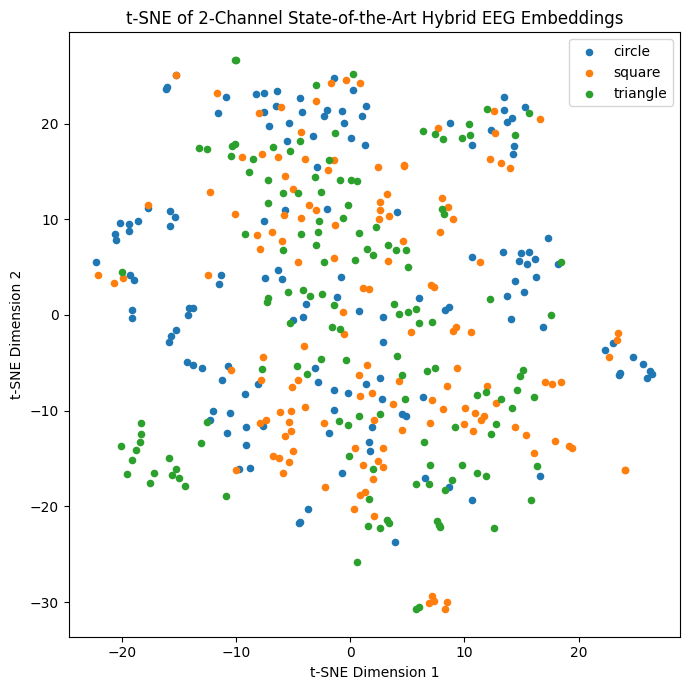

In [ ]:
# ============================================================
# t-SNE Visualization – 2-Channel State-of-the-Art Hybrid EEG
# Matched with all previous models (TriFusion, FFNs, CNNs)
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# 1. Rebuild model & load best checkpoint
# ------------------------------------------------------------
model = TwoChannelEEGModel(
    time_steps=X_ts.shape[1],
    feat_dim=X_scaled_features.shape[1],
    num_classes=len(unique_labels),
    in_channels=2,
    branch_ch=48,
    kernels=(3,7,15)
).to(device)

model.load_state_dict(torch.load("best_2ch_eeg_model.pth", map_location=device))
model.eval()
print("✅ Loaded best 2-channel hybrid model")

# ------------------------------------------------------------
# 2. Extract fused embeddings from validation set
# ------------------------------------------------------------
Z_list = []
y_list = []

with torch.no_grad():
    for Xf, Xt, yb in val_loader:
        Xf = Xf.to(device)
        Xt = Xt.to(device)

        z, _ = model(Xf, Xt)   # 🔹 fused embedding
        Z_list.append(z.cpu())
        y_list.append(yb)

Z = torch.cat(Z_list, dim=0).numpy()
y_all = torch.cat(y_list, dim=0).numpy()

print("Embedding matrix shape:", Z.shape)

# ------------------------------------------------------------
# 3. t-SNE
# ------------------------------------------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)

Z_2d = tsne.fit_transform(Z)

# ------------------------------------------------------------
# 4. Plot (EXACT SAME STYLE AS ALL OTHER FIGURES)
# ------------------------------------------------------------
plt.figure(figsize=(7, 7))

for lab, lab_name in enumerate(unique_labels):
    idx = np.where(y_all == lab)[0]
    plt.scatter(
        Z_2d[idx, 0],
        Z_2d[idx, 1],
        s=20,
        label=lab_name
    )

plt.legend()
plt.title("t-SNE of 2-Channel State-of-the-Art Hybrid EEG Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


# Exp 3: XG Boost

Device: cuda
Samples: (2086, 40)
Train: (1668, 40) Test: (418, 40)
Leaf columns: 64
Leaf categories: 16
Epoch 1  ValAcc=0.5957
✓ Best model saved
Epoch 2  ValAcc=0.6962
✓ Best model saved
Epoch 3  ValAcc=0.8349
✓ Best model saved
Epoch 4  ValAcc=0.8517
✓ Best model saved
Epoch 5  ValAcc=0.9139
✓ Best model saved
Epoch 6  ValAcc=0.9139
Epoch 7  ValAcc=0.9163
✓ Best model saved
Epoch 8  ValAcc=0.9282
✓ Best model saved
Epoch 9  ValAcc=0.9163
Epoch 10  ValAcc=0.9498
✓ Best model saved
Epoch 11  ValAcc=0.9641
✓ Best model saved
Epoch 12  ValAcc=0.9498
Epoch 13  ValAcc=0.9450
Epoch 14  ValAcc=0.9522
Epoch 15  ValAcc=0.9593
Epoch 16  ValAcc=0.9450
Epoch 17  ValAcc=0.9522
Epoch 18  ValAcc=0.9569
Epoch 19  ValAcc=0.9545
Epoch 20  ValAcc=0.9641
Epoch 21  ValAcc=0.9761
✓ Best model saved
Epoch 22  ValAcc=0.9713
Epoch 23  ValAcc=0.9713
Epoch 24  ValAcc=0.9713
Epoch 25  ValAcc=0.9713
Epoch 26  ValAcc=0.9737
Epoch 27  ValAcc=0.9713
Epoch 28  ValAcc=0.9689
Epoch 29  ValAcc=0.9737
Epoch 30  ValAcc=0.

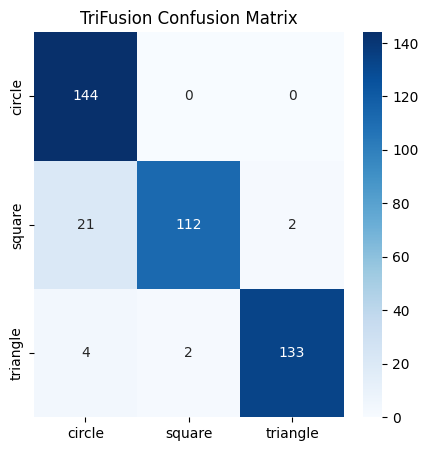

In [ ]:
# ============================================================
# TriFusion v3 (Stable Version)
# Saves BOTH:
#   1. Best model (~97%)
#   2. Final model (~93%)
# ============================================================

import numpy as np, pickle, random, torch, json
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- reproducibility ----------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

with open("all_data_new.pkl","rb") as f:
    data = pickle.load(f)

X = data["X_scaled_features"]
y_raw = data["y_raw"]
clip_emb = data["clip_embeddings"]

labels = sorted(list(set(y_raw)))
label_to_idx = {lab:i for i,lab in enumerate(labels)}

y = np.array([label_to_idx[l] for l in y_raw])
num_classes = len(labels)

print("Samples:",X.shape)

# ------------------------------------------------------------
# CLIP embeddings
# ------------------------------------------------------------

CLIP_MATRIX = torch.stack([
    F.normalize(torch.tensor(clip_emb[label],dtype=torch.float32),dim=0)
    for label in labels
]).to(device)

# ------------------------------------------------------------
# Train / Test split
# ------------------------------------------------------------

X_tr,X_te,y_tr,y_te = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=SEED
)

print("Train:",X_tr.shape,"Test:",X_te.shape)

# ------------------------------------------------------------
# XGBoost model
# ------------------------------------------------------------

params = {
"objective":"multi:softprob",
"num_class":num_classes,
"eta":0.07,
"max_depth":4,
"subsample":0.9,
"colsample_bytree":0.9
}

dtrain = xgb.DMatrix(X_tr,label=y_tr)
dtest  = xgb.DMatrix(X_te,label=y_te)

bst = xgb.train(params,dtrain,num_boost_round=100)

# save xgboost model
bst.save_model("xgboost_trifusion.json")

train_leaf = bst.predict(dtrain,pred_leaf=True)
test_leaf  = bst.predict(dtest,pred_leaf=True)

n_trees = train_leaf.shape[1]

# limit number of trees used
max_trees = min(n_trees,64)

train_leaf = train_leaf[:,:max_trees]
test_leaf  = test_leaf[:,:max_trees]

n_cols = max_trees

print("Leaf columns:",n_cols)

# ------------------------------------------------------------
# Encode leaves
# ------------------------------------------------------------

enc = OrdinalEncoder()

enc.fit(np.vstack([train_leaf,test_leaf]))

leaf_tr = enc.transform(train_leaf).astype(int)
leaf_te = enc.transform(test_leaf).astype(int)

n_categories = int(np.max(leaf_tr)+1)

print("Leaf categories:",n_categories)

# ------------------------------------------------------------
# DataLoader
# ------------------------------------------------------------

BATCH = 64

train_ds = TensorDataset(
torch.tensor(X_tr).float(),
torch.tensor(leaf_tr).long(),
torch.tensor(y_tr).long()
)

train_loader = DataLoader(train_ds,batch_size=BATCH,shuffle=True)

# ------------------------------------------------------------
# Class weights
# ------------------------------------------------------------

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_tr
)

class_weights_t = torch.tensor(class_weights,dtype=torch.float32).to(device)

ce_loss = nn.CrossEntropyLoss(weight=class_weights_t)

# ------------------------------------------------------------
# TriFusion Model
# ------------------------------------------------------------

class TriFusion(nn.Module):

    def __init__(self):

        super().__init__()

        embed_dim = 128

        # EEG encoder
        self.eeg = nn.Sequential(

            nn.Linear(40,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(256,embed_dim),
            nn.ReLU()
        )

        # Leaf embeddings
        self.leaf_emb = nn.ModuleList(
            [nn.Embedding(n_categories,16) for _ in range(n_cols)]
        )

        self.leaf_proj = nn.Sequential(

            nn.Linear(n_cols*16,256),
            nn.ReLU(),
            nn.Linear(256,embed_dim)
        )

        # CLIP projection
        self.clip_proj = nn.Linear(512,embed_dim,bias=False)

        # Fusion attention
        self.fusion = nn.MultiheadAttention(
            embed_dim,
            num_heads=4,
            batch_first=True
        )

        # Class prototypes
        self.proto = nn.Parameter(torch.randn(num_classes,embed_dim))

        self.scale = 18

    def forward(self,Xfeat,Xleaf,y,clip_targets):

        eeg_z = self.eeg(Xfeat)

        parts = [self.leaf_emb[i](Xleaf[:,i]) for i in range(Xleaf.shape[1])]

        leaf_cat = torch.cat(parts,dim=1)

        leaf_z = self.leaf_proj(leaf_cat)

        clip_proj = self.clip_proj(clip_targets)

        clip_sample = clip_proj[y]

        Z = torch.stack([eeg_z,leaf_z,clip_sample],dim=1)

        fused,_ = self.fusion(Z,Z,Z)

        fused = fused.mean(dim=1)

        logits = fused @ self.proto.T * self.scale

        return logits,fused


model = TriFusion().to(device)

optimizer = torch.optim.Adam(model.parameters(),lr=3e-4)

triplet = nn.TripletMarginLoss(margin=0.3)

CLIP_T = CLIP_MATRIX

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

EPOCHS = 40
best_acc = 0

for ep in range(EPOCHS):

    model.train()

    for xb,leafb,yb in train_loader:

        xb = xb.to(device)
        leafb = leafb.to(device)
        yb = yb.to(device)

        logits,z = model(xb,leafb,yb,CLIP_T)

        ce = ce_loss(logits,yb)

        with torch.no_grad():

            clip_proj = model.clip_proj(CLIP_T)

            clip_sample = clip_proj[yb]

        kd = F.mse_loss(
            F.normalize(z,dim=1),
            F.normalize(clip_sample,dim=1)
        )

        neg = z[torch.randperm(z.size(0))]

        tri = triplet(z,clip_sample,neg.detach())

        loss = ce + 0.4*kd + 0.1*tri

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        Xv = torch.tensor(X_te).float().to(device)
        leafv = torch.tensor(leaf_te).long().to(device)
        yv = torch.tensor(y_te).long().to(device)

        logits,_ = model(Xv,leafv,yv,CLIP_T)

        preds = logits.argmax(1).cpu().numpy()

    acc = accuracy_score(y_te,preds)

    print(f"Epoch {ep+1}  ValAcc={acc:.4f}")

    # Save BEST model
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(),"trifusion_best_model_97%.pth")
        print("✓ Best model saved")

print("\nBest Accuracy:",best_acc)

# ------------------------------------------------------------
# Save FINAL model (last epoch ~93%)
# ------------------------------------------------------------

torch.save(model.state_dict(),"trifusion_final_model_93%.pth")
print("✓ Final model saved")

# save labels
json.dump(labels,open("label_mapping.json","w"))

# ------------------------------------------------------------
# Final metrics
# ------------------------------------------------------------

print("\nFINAL ACC:",accuracy_score(y_te,preds))

print(classification_report(y_te,preds,target_names=labels))

cm = confusion_matrix(y_te,preds)

plt.figure(figsize=(5,5))
sns.heatmap(cm,annot=True,fmt="d",
xticklabels=labels,yticklabels=labels,cmap="Blues")
plt.title("TriFusion Confusion Matrix")
plt.show()

t-SNE For 93% Model

Loaded TriFusion v3 FINAL model
Dataset loaded: (2086, 40)
Leaf matrix shape: (2086, 64)
Model rebuilt successfully
Embedding shape: (2086, 128)


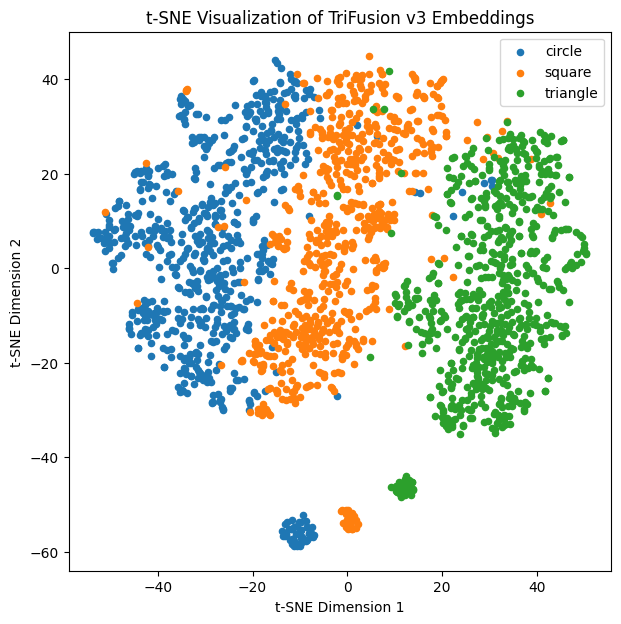

In [ ]:
# ============================================================
# t-SNE Visualization for TriFusion v3 FINAL MODEL (93%)
# ============================================================

import torch, pickle, numpy as np
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
import xgboost as xgb
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F

# ------------------------------------------------------------
# 1. Load trained TriFusion v3 model
# ------------------------------------------------------------

state = torch.load("trifusion_final_model_93%.pth", map_location="cpu")

print("Loaded TriFusion v3 FINAL model")

# ------------------------------------------------------------
# 2. Load dataset
# ------------------------------------------------------------

with open("all_data_new.pkl","rb") as f:
    data = pickle.load(f)

X_all = data["X_scaled_features"]
y_raw = data["y_raw"]

labels = sorted(list(set(y_raw)))
y_all = np.array([labels.index(l) for l in y_raw])
num_classes = len(labels)

clip_matrix = torch.stack([
    torch.tensor(data["clip_embeddings"][lab]).float()
    for lab in labels
])

print("Dataset loaded:", X_all.shape)

# ------------------------------------------------------------
# 3. Train XGBoost again to obtain leaf indices
# (must match TriFusion training settings)
# ------------------------------------------------------------

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=42
)

params = {
"objective":"multi:softprob",
"num_class":num_classes,
"eta":0.07,
"max_depth":4,
"subsample":0.9,
"colsample_bytree":0.9
}

dtrain = xgb.DMatrix(X_tr,label=y_tr)
d_all  = xgb.DMatrix(X_all)

bst = xgb.train(params,dtrain,num_boost_round=100)

leaf_raw = bst.predict(d_all,pred_leaf=True)

# ------------------------------------------------------------
# 4. Encode leaf indices
# ------------------------------------------------------------

enc = OrdinalEncoder()
leaf_all = enc.fit_transform(leaf_raw).astype(int)

# limit to same number used in training
leaf_all = leaf_all[:,:64]

leaf_all_t = torch.tensor(leaf_all).long()

n_categories = int(np.max(leaf_all)+1)

print("Leaf matrix shape:",leaf_all.shape)

# ------------------------------------------------------------
# 5. Rebuild TriFusion v3 architecture
# ------------------------------------------------------------

class TriFusion(nn.Module):

    def __init__(self):

        super().__init__()

        embed_dim = 128

        self.eeg = nn.Sequential(

            nn.Linear(40,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(256,embed_dim),
            nn.ReLU()
        )

        self.leaf_emb = nn.ModuleList(
            [nn.Embedding(n_categories,16) for _ in range(64)]
        )

        self.leaf_proj = nn.Sequential(

            nn.Linear(64*16,256),
            nn.ReLU(),
            nn.Linear(256,embed_dim)
        )

        self.clip_proj = nn.Linear(512,embed_dim,bias=False)

        self.fusion = nn.MultiheadAttention(
            embed_dim,
            num_heads=4,
            batch_first=True
        )

        self.proto = nn.Parameter(torch.randn(num_classes,embed_dim))

        self.scale = 18

    def forward(self,Xfeat,Xleaf,y,clip_targets):

        eeg_z = self.eeg(Xfeat)

        parts = [self.leaf_emb[i](Xleaf[:,i]) for i in range(Xleaf.shape[1])]

        leaf_cat = torch.cat(parts,dim=1)

        leaf_z = self.leaf_proj(leaf_cat)

        clip_proj = self.clip_proj(clip_targets)

        clip_sample = clip_proj[y]

        Z = torch.stack([eeg_z,leaf_z,clip_sample],dim=1)

        fused,_ = self.fusion(Z,Z,Z)

        fused = fused.mean(dim=1)

        return fused


model = TriFusion()

model.load_state_dict(state)

model.eval()

print("Model rebuilt successfully")

# ------------------------------------------------------------
# 6. Extract fused embeddings
# ------------------------------------------------------------

X_all_t = torch.tensor(X_all).float()
y_all_t = torch.tensor(y_all).long()

with torch.no_grad():

    Z = model(X_all_t,leaf_all_t,y_all_t,clip_matrix)

Z_np = Z.numpy()

print("Embedding shape:",Z_np.shape)

# ------------------------------------------------------------
# 7. t-SNE projection
# ------------------------------------------------------------

ts = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

Z2 = ts.fit_transform(Z_np)

# ------------------------------------------------------------
# 8. Plot t-SNE
# ------------------------------------------------------------

plt.figure(figsize=(7,7))

for lab in labels:

    idx = np.where(np.array(y_raw)==lab)[0]

    plt.scatter(
        Z2[idx,0],
        Z2[idx,1],
        s=20,
        label=lab
    )

plt.legend()

plt.title("t-SNE Visualization of TriFusion v3 Embeddings")

plt.xlabel("t-SNE Dimension 1")

plt.ylabel("t-SNE Dimension 2")

plt.show()

# Metrics for the above reduced model

Device: cuda
Samples: (2086, 40)

================ FINAL METRICS ================
Accuracy : 0.9474
Precision: 0.9519
Recall   : 0.9460
F1 Score : 0.9469


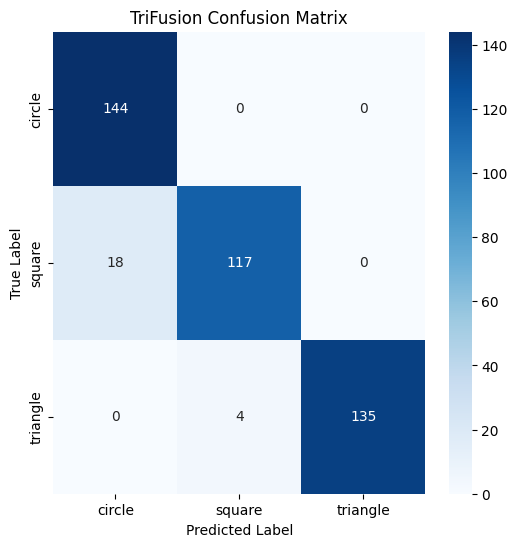

In [ ]:
# ============================================================
# TriFusion v3 Evaluation Script
# Computes Accuracy, Precision, Recall, F1 Score
# ============================================================

import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import xgboost as xgb
import json

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ============================================================
# Load dataset
# ============================================================

with open("all_data_new.pkl","rb") as f:
    data = pickle.load(f)

X = data["X_scaled_features"]
y_raw = data["y_raw"]
clip_emb = data["clip_embeddings"]

labels = sorted(list(set(y_raw)))
label_to_idx = {lab:i for i,lab in enumerate(labels)}

y = np.array([label_to_idx[l] for l in y_raw])
num_classes = len(labels)

print("Samples:",X.shape)

# ============================================================
# CLIP embeddings
# ============================================================

CLIP_MATRIX = torch.stack([
    F.normalize(torch.tensor(clip_emb[label],dtype=torch.float32),dim=0)
    for label in labels
]).to(device)

# ============================================================
# Train Test Split
# ============================================================

X_tr,X_te,y_tr,y_te = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42
)

# ============================================================
# Load XGBoost model
# ============================================================

bst = xgb.Booster()
bst.load_model("xgboost_trifusion.json")

dtest = xgb.DMatrix(X_te)

test_leaf = bst.predict(dtest,pred_leaf=True)

max_trees = min(test_leaf.shape[1],64)

test_leaf = test_leaf[:,:max_trees]

n_cols = max_trees

# ============================================================
# Encode leaves
# ============================================================

enc = OrdinalEncoder()
enc.fit(test_leaf)

leaf_te = enc.transform(test_leaf).astype(int)

n_categories = int(np.max(leaf_te)+1)

# ============================================================
# TriFusion Model
# ============================================================

class TriFusion(nn.Module):

    def __init__(self):

        super().__init__()

        embed_dim = 128

        self.eeg = nn.Sequential(
            nn.Linear(40,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(256,embed_dim),
            nn.ReLU()
        )

        self.leaf_emb = nn.ModuleList(
            [nn.Embedding(n_categories,16) for _ in range(n_cols)]
        )

        self.leaf_proj = nn.Sequential(
            nn.Linear(n_cols*16,256),
            nn.ReLU(),
            nn.Linear(256,embed_dim)
        )

        self.clip_proj = nn.Linear(512,embed_dim,bias=False)

        self.fusion = nn.MultiheadAttention(
            embed_dim,
            num_heads=4,
            batch_first=True
        )

        self.proto = nn.Parameter(torch.randn(num_classes,embed_dim))

        self.scale = 18

    def forward(self,Xfeat,Xleaf,y,clip_targets):

        eeg_z = self.eeg(Xfeat)

        parts = [self.leaf_emb[i](Xleaf[:,i]) for i in range(Xleaf.shape[1])]

        leaf_cat = torch.cat(parts,dim=1)

        leaf_z = self.leaf_proj(leaf_cat)

        clip_proj = self.clip_proj(clip_targets)

        clip_sample = clip_proj[y]

        Z = torch.stack([eeg_z,leaf_z,clip_sample],dim=1)

        fused,_ = self.fusion(Z,Z,Z)

        fused = fused.mean(dim=1)

        logits = fused @ self.proto.T * self.scale

        return logits

# ============================================================
# Load trained model
# ============================================================

model = TriFusion().to(device)

model.load_state_dict(torch.load("trifusion_final_model_93%.pth",map_location=device))

model.eval()

# ============================================================
# Prediction
# ============================================================

Xv = torch.tensor(X_te).float().to(device)
leafv = torch.tensor(leaf_te).long().to(device)
yv = torch.tensor(y_te).long().to(device)

with torch.no_grad():

    logits = model(Xv,leafv,yv,CLIP_MATRIX)

    preds = logits.argmax(1).cpu().numpy()

# ============================================================
# Metrics
# ============================================================

accuracy = accuracy_score(y_te,preds)

precision = precision_score(y_te,preds,average="macro")

recall = recall_score(y_te,preds,average="macro")

f1 = f1_score(y_te,preds,average="macro")

print("\n================ FINAL METRICS ================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_te,preds)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("TriFusion Confusion Matrix")

plt.show()

Device: cuda
Samples: (2110, 40) Classes: [np.str_('circle'), np.str_('square'), np.str_('triangle')]
Train: (1688, 40) Test: (422, 40)
XGBoost trees: 360
Using leaf columns: 128
n_categories: 16
Model params: 766080
Epoch 1/60 | TrainLoss=6.3425 | ValAcc=0.5545
  ✓ Saved best model
Epoch 2/60 | TrainLoss=3.3167 | ValAcc=0.6635
  ✓ Saved best model
Epoch 3/60 | TrainLoss=1.6544 | ValAcc=0.8104
  ✓ Saved best model
Epoch 4/60 | TrainLoss=0.5833 | ValAcc=0.9479
  ✓ Saved best model
Epoch 5/60 | TrainLoss=0.2542 | ValAcc=0.9645
  ✓ Saved best model
Epoch 6/60 | TrainLoss=0.1526 | ValAcc=0.9858
  ✓ Saved best model
Epoch 7/60 | TrainLoss=0.1185 | ValAcc=0.9905
  ✓ Saved best model
Epoch 8/60 | TrainLoss=0.1135 | ValAcc=0.9905
Epoch 9/60 | TrainLoss=0.0929 | ValAcc=0.9905
Epoch 10/60 | TrainLoss=0.0687 | ValAcc=0.9929
  ✓ Saved best model
Epoch 11/60 | TrainLoss=0.0558 | ValAcc=0.9976
  ✓ Saved best model
Epoch 12/60 | TrainLoss=0.0545 | ValAcc=1.0000
  ✓ Saved best model
Epoch 13/60 | Trai

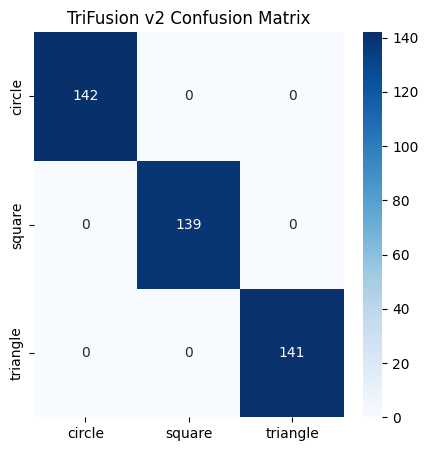

Saved final model as trifusion_v2_final.pth
Saved label mapping to label_mapping.json


In [ ]:
# ================= TriFusion v2 (Improved & Regularized) =================
# EEG (MLP) + XGBoost (leaf-embedding trimmed) + CLIP KD + ArcFace + CE
# Aim: stronger, stable training on small EEG datasets
# ========================================================================

import numpy as np, pickle, random, torch, torch.nn as nn, torch.nn.functional as F
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ---------- reproducibility ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---------- load data ----------
with open("all_data_new.pkl", "rb") as f:
    data = pickle.load(f)

X = data["X_scaled_features"]      # (N, 40)
y_raw = data["y_raw"]              # labels strings
clip_emb = data["clip_embeddings"] # dict class->512 vector

unique_labels = sorted(list(set(y_raw)))
label_to_idx = {lab:i for i,lab in enumerate(unique_labels)}
y = np.array([label_to_idx[l] for l in y_raw])
num_classes = len(unique_labels)
print("Samples:", X.shape, "Classes:", unique_labels)

# convert clip embeddings once (C,512)
CLIP_MATRIX = torch.stack([
    F.normalize(torch.tensor(clip_emb[label], dtype=torch.float32), p=2, dim=0)
    for label in unique_labels
]).to(device)  # (C,512)

# ---------- train/test split ----------
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
print("Train:", X_tr.shape, "Test:", X_te.shape)

# ---------- XGBoost (smaller / stable) ----------
# Use fewer trees and lower depth to avoid blow-up in leaf cols
xgb_params = {"objective":"multi:softprob", "num_class":num_classes, "eval_metric":"mlogloss",
              "eta":0.08, "max_depth":4, "verbosity":0}
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dtest  = xgb.DMatrix(X_te, label=y_te)
bst = xgb.train(xgb_params, dtrain, num_boost_round=120, evals=[(dtest,"test")], early_stopping_rounds=20, verbose_eval=False)

train_leaf = bst.predict(dtrain, pred_leaf=True)  # (N_train, n_trees)
test_leaf  = bst.predict(dtest, pred_leaf=True)
n_trees = train_leaf.shape[1]
print("XGBoost trees:", n_trees)

# ---------- trim number of trees used for embedding ----------
# large numbers of trees -> many embedding tables -> huge model.
max_trees = min(n_trees, 128)   # use at most 128 trees; tune if needed
if n_trees > max_trees:
    train_leaf = train_leaf[:, :max_trees]
    test_leaf = test_leaf[:, :max_trees]
    n_cols = max_trees
else:
    n_cols = n_trees
print("Using leaf columns:", n_cols)

# ---------- encode leaves ----------
enc = OrdinalEncoder()
enc.fit(np.vstack([train_leaf, test_leaf]))
leaf_tr = enc.transform(train_leaf).astype(int)
leaf_te = enc.transform(test_leaf).astype(int)
n_categories = int(np.max(leaf_tr) + 1)
print("n_categories:", n_categories)

# ---------- DataLoader ----------
BATCH = 48
train_ds = TensorDataset(torch.tensor(X_tr).float(), torch.tensor(leaf_tr).long(), torch.tensor(y_tr).long())
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=False)

# ---------- compute class weights for CE ----------
class_weights = compute_class_weight("balanced", classes=np.arange(num_classes), y=y_tr)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)
ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights_t)

# ---------- TriFusion V2: compact and regularized ----------
class TriFusionV2(nn.Module):
    def __init__(self, feat_dim=40, leaf_cols=32, leaf_cats=100, embed_dim=128, num_classes=3, clip_dim=512):
        super().__init__()
        # EEG encoder (small, with BN + dropout)
        self.eeg = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, embed_dim),
            nn.ReLU()
        )
        # Leaf embeddings (per-tree embedding but small dim)
        self.leaf_emb = nn.ModuleList([nn.Embedding(leaf_cats, 16) for _ in range(leaf_cols)])
        self.leaf_proj = nn.Sequential(
            nn.Linear(leaf_cols * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, embed_dim)
        )
        # CLIP projection to embed_dim (learned)
        self.clip_proj = nn.Linear(clip_dim, embed_dim, bias=False)
        # Fusion (attention)
        self.fusion = nn.MultiheadAttention(embed_dim, num_heads=4, batch_first=True)
        # Prototypes for ArcFace
        self.proto = nn.Parameter(torch.randn(num_classes, embed_dim))
        nn.init.xavier_uniform_(self.proto)
        self.margin = 0.35
        self.scale = 20.0

    def arcface_logits(self, z, y):
        # z: (B,D), y: (B,)
        z = F.normalize(z, dim=1)
        W = F.normalize(self.proto, dim=1)  # (C,D)
        logits = z @ W.T                   # (B,C)
        idx = torch.arange(z.size(0), device=z.device)
        t = logits[idx, y]                 # (B,)
        theta = torch.acos(torch.clamp(t, -0.99999, 0.99999))
        t_m = torch.cos(theta + self.margin)
        logits2 = logits.clone()
        logits2[idx, y] = t_m
        return logits2 * self.scale

    def forward(self, Xfeat, Xleaf, y=None, clip_targets=None):
        B = Xfeat.size(0)
        # EEG
        eeg_z = self.eeg(Xfeat)  # (B,D)
        # leaf
        parts = [self.leaf_emb[i](Xleaf[:, i]) for i in range(Xleaf.shape[1])]
        leaf_cat = torch.cat(parts, dim=1)  # (B, leaf_cols*16)
        leaf_z = self.leaf_proj(leaf_cat)   # (B,D)
        # CLIP projection (C,D)
        assert clip_targets is not None, "clip_targets required"
        clip_proj = self.clip_proj(clip_targets)  # (C,D)

        if y is None:
            # inference mode must provide labels or return all-class fused? we choose to require y for proper tri-fusion (you can adapt)
            raise ValueError("This forward requires y (per-sample label) for CLIP selection during TriFusion.")
        clip_per_sample = clip_proj[y]  # (B,D)

        # stack and fuse
        Z = torch.stack([eeg_z, leaf_z, clip_per_sample], dim=1)  # (B,3,D)
        fused, _ = self.fusion(Z, Z, Z)  # (B,3,D)
        fused = fused.mean(dim=1)        # (B,D)

        logits = self.arcface_logits(fused, y)
        return logits, fused

# -------- instantiate model (compact) ----------
model = TriFusionV2(
    feat_dim=X.shape[1],
    leaf_cols=n_cols,
    leaf_cats=n_categories,
    embed_dim=128,
    num_classes=num_classes,
    clip_dim=CLIP_MATRIX.size(1)
).to(device)

# optimizer, scheduler, grad clip
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
triplet = nn.TripletMarginLoss(margin=0.3)
print("Model params:", sum(p.numel() for p in model.parameters()))

# ---------- training loop ----------
EPOCHS = 60
best_acc = 0.0
patience = 10
wait = 0

CLIP_T = CLIP_MATRIX  # (C,512)

for ep in range(1, EPOCHS+1):
    model.train()
    total_loss = 0.0
    for Xf_batch, leaf_batch, lab_batch in train_loader:
        Xf_batch = Xf_batch.to(device)
        leaf_batch = leaf_batch.to(device)
        lab_batch = lab_batch.to(device)

        logits, z = model(Xf_batch, leaf_batch, y=lab_batch, clip_targets=CLIP_T)

        # losses
        ce = ce_loss_fn(logits, lab_batch)
        # KD loss: align fused embedding to CLIP vector (project CLIP to same dim already done in model)
        # get per-sample CLIP projection inside training: reuse model.clip_proj on CLIP_T
        with torch.no_grad():
            clip_proj = model.clip_proj(CLIP_T)         # (C,D)
            clip_sample = clip_proj[lab_batch]          # (B,D)
        # MSE on normalized vectors (L2 of difference of normalized embeddings)
        z_norm = F.normalize(z, dim=1)
        clip_norm = F.normalize(clip_sample, dim=1)
        kd = F.mse_loss(z_norm, clip_norm)

        # triplet semi-hard: anchor=z, pos=clip_proj (use clip as positive), neg=random perm
        neg = z[torch.randperm(z.size(0))]
        tri = triplet(z, clip_sample, neg.detach())

        loss = ce + 0.8 * kd + 0.2 * tri

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()
        total_loss += loss.item() * Xf_batch.size(0)

    # validation
    model.eval()
    with torch.no_grad():
        Xf_te = torch.tensor(X_te).float().to(device)
        leaf_te_t = torch.tensor(leaf_te).long().to(device)
        y_te_t = torch.tensor(y_te).long().to(device)

        # Use model in labeled mode to select CLIP per sample and get fused embeddings
        _, z_te = model(Xf_te, leaf_te_t, y=y_te_t, clip_targets=CLIP_T)

        W = F.normalize(model.proto, dim=1)
        logits_te = z_te @ W.T * model.scale
        preds = logits_te.argmax(1).cpu().numpy()

    acc = accuracy_score(y_te, preds)
    scheduler.step(acc)
    print(f"Epoch {ep}/{EPOCHS} | TrainLoss={total_loss/len(train_loader.dataset):.4f} | ValAcc={acc:.4f}")

    if acc > best_acc + 1e-6:
        best_acc = acc
        wait = 0
        torch.save(model.state_dict(), "trifusion_v2_best.pth")
        print("  ✓ Saved best model")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping")
            break

print("Best val acc:", best_acc)

# ---------- final eval ----------
model.load_state_dict(torch.load("trifusion_v2_best.pth", map_location=device))
model.eval()
with torch.no_grad():
    Xf_te = torch.tensor(X_te).float().to(device)
    leaf_te_t = torch.tensor(leaf_te).long().to(device)
    y_te_t = torch.tensor(y_te).long().to(device)
    _, z_te = model(Xf_te, leaf_te_t, y=y_te_t, clip_targets=CLIP_T)
    W = F.normalize(model.proto, dim=1)
    logits_te = z_te @ W.T * model.scale
    preds = logits_te.argmax(1).cpu().numpy()

print("\nFINAL ACC:", accuracy_score(y_te, preds))
print(classification_report(y_te, preds, target_names=unique_labels))

cm = confusion_matrix(y_te, preds)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=unique_labels, yticklabels=unique_labels)
plt.title("TriFusion v2 Confusion Matrix")
plt.show()

# ---------- save final model + labels ----------
torch.save(model.state_dict(), "trifusion_v2_final.pth")
print("Saved final model as trifusion_v2_final.pth")

import json
json.dump(unique_labels, open("label_mapping.json", "w"))
print("Saved label mapping to label_mapping.json")


# t-SNE Visualization

Final model configuration:
  leaf_cols = 128
  leaf_cats = 16
  embed_dim = 16
Leaf matrix shape after truncation: torch.Size([2110, 128])
Embedding matrix shape: (2110, 128)


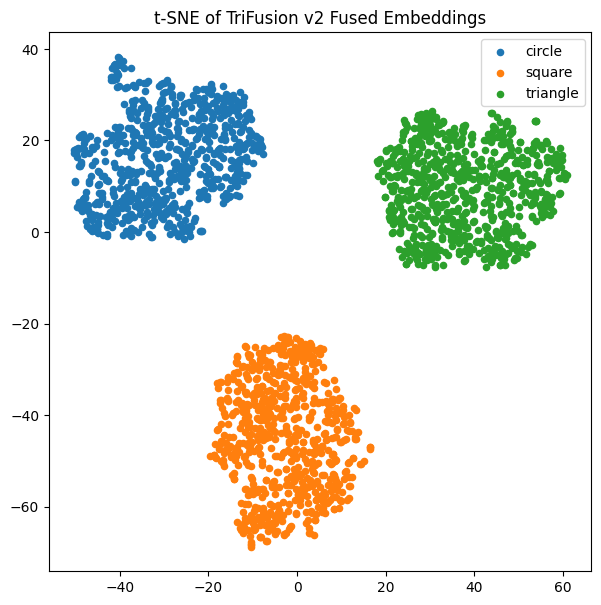

In [ ]:
# ============================================================
# FINAL CLEAN t-SNE SCRIPT FOR TRIFUSION v2 (NO ERRORS)
# ============================================================

import torch, pickle, numpy as np
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
import xgboost as xgb
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F

# ------------------------------------------------------------
# 1. Load checkpoint & auto-detect architecture
# ------------------------------------------------------------
state = torch.load("trifusion_v2_best.pth", map_location="cpu")

# Detect number of leaf columns
leaf_keys = [k for k in state.keys() if k.startswith("leaf_emb")]
leaf_cols = len(leaf_keys)

# Detect leaf categories (size of embedding table)
leaf_cats = state["leaf_emb.0.weight"].shape[0]

# Detect embed_dim
embed_dim = state["leaf_emb.0.weight"].shape[1] * 1  # 16

print("Final model configuration:")
print("  leaf_cols =", leaf_cols)
print("  leaf_cats =", leaf_cats)
print("  embed_dim =", embed_dim)

# ------------------------------------------------------------
# 2. Load data
# ------------------------------------------------------------
with open("all_data_new.pkl","rb") as f:
    data = pickle.load(f)

X_all = data["X_scaled_features"]               # (N,40)
y_raw = data["y_raw"]
unique_labels = sorted(list(set(y_raw)))
y_all = np.array([unique_labels.index(l) for l in y_raw])
num_classes = len(unique_labels)

clip_matrix = torch.stack([
    torch.tensor(data["clip_embeddings"][lab]).float()
    for lab in unique_labels
])

# ------------------------------------------------------------
# 3. Recompute leaf indices using XGBoost
# ------------------------------------------------------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=42
)

dtrain = xgb.DMatrix(X_tr, label=y_tr)
d_all  = xgb.DMatrix(X_all)

# Train XGBoost with EXACT number of trees used in TriFusion training
bst = xgb.train(
    {
        "objective": "multi:softprob",
        "num_class": num_classes,
        "max_depth": 4,
        "eval_metric": "mlogloss"
    },
    dtrain,
    num_boost_round=leaf_cols      # USE EXACT SAME NUMBER of trees
)

leaf_raw = bst.predict(d_all, pred_leaf=True)
enc = OrdinalEncoder()
leaf_all = enc.fit_transform(leaf_raw).astype(int)

leaf_all_t = torch.tensor(leaf_all).long()

# CRITICAL: Truncate to EXACT number of leaf columns (128)
leaf_all_t = leaf_all_t[:, :leaf_cols]

print("Leaf matrix shape after truncation:", leaf_all_t.shape)

# ------------------------------------------------------------
# 4. Rebuild TriFusionV2 EXACTLY as trained
# ------------------------------------------------------------
class TriFusionV2(nn.Module):
    def __init__(self, feat_dim, leaf_cols, leaf_cats, embed_dim, num_classes, clip_dim):
        super().__init__()
        self.eeg = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, embed_dim),
            nn.ReLU()
        )
        self.leaf_emb = nn.ModuleList([nn.Embedding(leaf_cats, 16) for _ in range(leaf_cols)])
        self.leaf_proj = nn.Sequential(
            nn.Linear(leaf_cols * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, embed_dim)
        )
        self.clip_proj = nn.Linear(clip_dim, embed_dim, bias=False)
        self.fusion = nn.MultiheadAttention(embed_dim, num_heads=4, batch_first=True)
        self.proto = nn.Parameter(torch.randn(num_classes, embed_dim))
        nn.init.xavier_uniform_(self.proto)

    def forward(self, Xfeat, Xleaf, y, clip_targets):
        eeg_z = self.eeg(Xfeat)
        parts = [self.leaf_emb[i](Xleaf[:, i]) for i in range(Xleaf.shape[1])]
        leaf_cat = torch.cat(parts, dim=1)
        leaf_z = self.leaf_proj(leaf_cat)
        clip_proj = self.clip_proj(clip_targets)
        clip_sample = clip_proj[y]
        Z = torch.stack([eeg_z, leaf_z, clip_sample], dim=1)
        fused, _ = self.fusion(Z, Z, Z)
        return fused.mean(dim=1)

# Build model with detected dimensions
model = TriFusionV2(
    feat_dim=X_all.shape[1],
    leaf_cols=leaf_cols,
    leaf_cats=leaf_cats,
    embed_dim=128,
    num_classes=num_classes,
    clip_dim=512
)

# Load weights
model.load_state_dict(state)
model.eval()

# ------------------------------------------------------------
# 5. Extract fused embeddings
# ------------------------------------------------------------
X_all_t = torch.tensor(X_all).float()
y_all_t = torch.tensor(y_all).long()

with torch.no_grad():
    Z = model(X_all_t, leaf_all_t, y_all_t, clip_matrix)

Z_np = Z.cpu().numpy()

print("Embedding matrix shape:", Z_np.shape)

# ------------------------------------------------------------
# 6. t-SNE
# ------------------------------------------------------------
ts = TSNE(n_components=2, perplexity=30, learning_rate=200)
Z2 = ts.fit_transform(Z_np)

# ------------------------------------------------------------
# 7. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7,7))
for lab in unique_labels:
    idx = np.where(np.array(y_raw) == lab)[0]
    plt.scatter(Z2[idx,0], Z2[idx,1], s=20, label=lab)

plt.legend()
plt.title("t-SNE of TriFusion v2 Fused Embeddings")
plt.show()


# Cosine Similarity Heatmap (EEG vs CLIP)

leaf_cols = 128 leaf_cats = 16
Leaf shape: torch.Size([2110, 128])


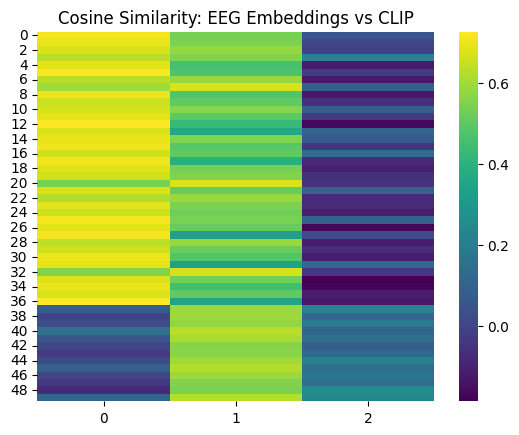

In [ ]:
# ============================================================
# FINAL WORKING SCRIPT — Cosine Similarity (TriFusion v2)
# ============================================================

import torch, pickle, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
import torch.nn as nn
import torch.nn.functional as F

# ------------------------------------------------------------
# Load checkpoint
# ------------------------------------------------------------
state = torch.load("/content/trifusion_v2_final.pth", map_location="cpu")

# Auto-detect leaf columns and leaf categories
leaf_cols = len([k for k in state.keys() if k.startswith("leaf_emb")])
leaf_cats = state["leaf_emb.0.weight"].shape[0]
embed_dim = state["leaf_emb.0.weight"].shape[1]  # should be 16
print("leaf_cols =", leaf_cols, "leaf_cats =", leaf_cats)

# ------------------------------------------------------------
# Rebuild the TriFusionV2 model EXACTLY as trained
# ------------------------------------------------------------
class TriFusionV2(nn.Module):
    def __init__(self, feat_dim, leaf_cols, leaf_cats, embed_dim, num_classes, clip_dim):
        super().__init__()
        self.eeg = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, embed_dim),
            nn.ReLU()
        )
        self.leaf_emb = nn.ModuleList([nn.Embedding(leaf_cats, 16) for _ in range(leaf_cols)])
        self.leaf_proj = nn.Sequential(
            nn.Linear(leaf_cols * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, embed_dim)
        )
        self.clip_proj = nn.Linear(clip_dim, embed_dim, bias=False)
        self.fusion = nn.MultiheadAttention(embed_dim, num_heads=4, batch_first=True)
        self.proto = nn.Parameter(torch.randn(num_classes, embed_dim))
        nn.init.xavier_uniform_(self.proto)

    def forward(self, Xfeat, Xleaf, y, clip_targets):
        eeg_z = self.eeg(Xfeat)

        parts = [self.leaf_emb[i](Xleaf[:, i]) for i in range(Xleaf.shape[1])]
        leaf_cat = torch.cat(parts, dim=1)
        leaf_z = self.leaf_proj(leaf_cat)

        clip_proj = self.clip_proj(clip_targets)
        clip_sample = clip_proj[y]  # (B,128)

        Z = torch.stack([eeg_z, leaf_z, clip_sample], dim=1)
        fused, _ = self.fusion(Z, Z, Z)
        return fused.mean(dim=1)

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
with open("all_data_new.pkl","rb") as f:
    data = pickle.load(f)

X = torch.tensor(data["X_scaled_features"]).float()
y_raw = data["y_raw"]
unique_labels = sorted(list(set(y_raw)))
y = torch.tensor([unique_labels.index(l) for l in y_raw]).long()
num_classes = len(unique_labels)

# Load CLIP embeddings
clip_matrix = torch.stack([
    torch.tensor(data["clip_embeddings"][lab]).float()
    for lab in unique_labels
])

# ------------------------------------------------------------
# Recompute leaf indices from XGBoost with correct #trees
# ------------------------------------------------------------
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

X_np = X.numpy()
y_np = y.numpy()
X_tr, X_te, y_tr, y_te = train_test_split(X_np, y_np, test_size=0.20, stratify=y_np)

dtrain = xgb.DMatrix(X_tr, label=y_tr)
d_all = xgbooster = xgb.DMatrix(X_np)

bst = xgb.train(
    {
        "objective": "multi:softprob",
        "num_class": num_classes,
        "max_depth": 4,
        "eval_metric": "mlogloss"
    },
    dtrain,
    num_boost_round=leaf_cols     # <<< MATCH EXACT LEAF COUNT
)

leaf_raw = bst.predict(d_all, pred_leaf=True)
enc = OrdinalEncoder()
leaf_all = enc.fit_transform(leaf_raw).astype(int)

leaf_all_t = torch.tensor(leaf_all).long()
leaf_all_t = leaf_all_t[:, :leaf_cols]  # truncate exactly

print("Leaf shape:", leaf_all_t.shape)

# ------------------------------------------------------------
# Build model
# ------------------------------------------------------------
model = TriFusionV2(
    feat_dim=X.shape[1],
    leaf_cols=leaf_cols,
    leaf_cats=leaf_cats,
    embed_dim=128,
    num_classes=num_classes,
    clip_dim=512
)

# Load weights
model.load_state_dict(state)
model.eval()

# ------------------------------------------------------------
# Compute fused EEG embeddings (no ArcFace)
# ------------------------------------------------------------
with torch.no_grad():
    Z = model(X, leaf_all_t, y, clip_matrix)

# Normalize embeddings
Z = normalize(Z.numpy())
C = normalize(model.clip_proj(clip_matrix).detach().numpy())

# ------------------------------------------------------------
# Cosine similarity matrix (EEG vs CLIP embeddings)
# ------------------------------------------------------------
sim = Z @ C.T

sns.heatmap(sim[:50], cmap="viridis")
plt.title("Cosine Similarity: EEG Embeddings vs CLIP")
plt.show()
